In [10]:
import numpy as np
import scipy as sp
import scipy.sparse, scipy.io, scipy.optimize
from scipy.special import expit
from scipy.sparse.linalg import eigsh
from scipy.sparse.linalg import eigs

import matplotlib.pyplot as plt
import matplotlib as mpl
import time
%matplotlib inline

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a', # Color blind color cycle
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=CB_color_cycle) 

clip_01 = lambda M : np.clip(M, a_min=0, a_max=1)

from DataPreprocess import *

In [2]:
# adj = read_cahepph(ca_hepph_path='./data/CA-HepPh.txt')
# adj = read_cora(content_path="./data/cora/cora.content", cites_path="./data/cora/cora.cites")
adj = read_cag_fb_wiki(ca_grqc_path="./data/CA-GrQc.txt")

Shape: (5241, 5241) nnz = 28968
Mean degree = 5.527189467658844


In [3]:
def lpca_loss(factors, adj_s, rank): # adj_s = shifted adj with -1's and +1's
    n_row, n_col = adj_s.shape
    U = factors[:n_row*rank].reshape(n_row, rank)
    V = factors[n_row*rank:].reshape(rank, n_col)
    logits = U @ V
    prob_wrong = expit(-logits * adj_s)
    loss = (np.logaddexp(0,-logits*adj_s)).sum()# / n_element    
    U_grad = -(prob_wrong * adj_s) @ V.T# / n_element
    V_grad = -U.T @ (prob_wrong * adj_s)# / n_element
    print(loss)
    return loss, np.concatenate((U_grad.flatten(), V_grad.flatten()))

save_interval = 100 # the number of iterations after which to save the embeddings

def callback_recm(x_i): # prints the loss and periodically saves the factors
    global iter_num
    iter_num += 1
    if iter_num % save_interval == 0:
        global factors, n_row, n_col, rank
        factors = x_i
        U = factors[:n_row*rank].reshape(n_row, rank)
        V = factors[n_row*rank:].reshape(rank, n_col)
        frob_error_norm = np.linalg.norm(clip_01(U@V) - adj) / sp.sparse.linalg.norm(adj)
        print(iter_num, "Frob_error_norm: ", frob_error_norm)
        
# generate a rank k TSVD factorization of a small sparse matrix adj
def factor_TSVD(adj, k):
    w, v = np.linalg.eigh(np.array(adj.todense()))
    order = np.argsort(np.abs(w))[::-1]
    w = w[order[:k]]
    v = v[:,order[:k]]
    U_tsvd, V_tsvd = v * np.sqrt(np.abs(w))[None,:], (np.sign(w)*np.sqrt(np.abs(w)))[:,None] * v.T
    return U_tsvd, V_tsvd

# compute number of triangles in the subgraph induced by the first i nodes
def get_num_tri(i):
    global adj_recon_sort
    sub_adj = adj_recon_sort[:i+1,:i+1]
    num_tri = (1. * sub_adj @ sub_adj @ sub_adj).diagonal().sum() / 6
    return num_tri

In [4]:
def lpca_fit(adj, rank_value, maxiter=2000):
    global iter_num, factors, n_row, n_col, rank, frob_error_norm
    rank = rank_value
    n_row, n_col = adj.shape
    factors = -1+2*np.random.random(size=(np.sum(adj.shape)*rank)) # initalize uniformly on [-1,+1]
    iter_num = 0
    U = factors[:n_row*rank].reshape(n_row, rank)
    V = factors[n_row*rank:].reshape(rank, n_col)
    
    res = scipy.optimize.minimize(lpca_loss, x0=factors, 
                              args=(-1 + 2*np.array(adj.todense()), rank), jac=True, method='L-BFGS-B', 
                              callback=callback_recm, 
                              options={'maxiter':maxiter}
                             )
    factors = res.x
    U = res.x[:n_row*rank].reshape(n_row, rank)
    V = res.x[n_row*rank:].reshape(rank, n_col)
    frob_error_norm = np.linalg.norm(1.*(U @ V > 0) - adj) / sp.sparse.linalg.norm(adj)
    print("LPCA Frob norm error: ", frob_error_norm)
    return U, V

def tsvd_fit(adj, rank):
    U_tsvd, V_tsvd = factor_TSVD(adj, rank)
    frob_error_norm = np.linalg.norm(clip_01(U_tsvd@V_tsvd) - adj) / sp.sparse.linalg.norm(adj)
    print("TSVD Frob norm error: ", frob_error_norm)
    return U_tsvd, V_tsvd

In [ ]:
U_lpca_16, V_lpca_16 = lpca_fit(adj, rank_value=16, maxiter=2000)

U_tsvd_16, V_tsvd_16 = tsvd_fit(adj, rank=16)
U_tsvd_128, V_tsvd_128 = tsvd_fit(adj, rank=128)

In [11]:
def recon_matrix(U, V, method="lpca"):
    logits = U @ V
    if method == "lpca":
        return expit(logits)
    elif method == "tsvd":
        return clip_01(logits)
    
def build_directed_edge_list(adj):
    adj = adj.tocoo()
    rows = adj.row
    cols = adj.col
    mask = rows != cols
    rows = rows[mask]
    cols = cols[mask]
    directed_edges = list(zip(rows, cols))
    return directed_edges

def build_nonbacktracking_matrix(adj):
    adj = adj.tocsr()
    directed_edges = build_directed_edge_list(adj)
    m = len(directed_edges)

    edge_index = {e: i for i, e in enumerate(directed_edges)}

    rows = []
    cols = []
    data = []

    for i, (u, v) in enumerate(directed_edges):
        nbrs = adj[v].indices
        for y in nbrs:
            if y == u:
                continue
            j = edge_index.get((v, y))
            if j is not None:
                rows.append(i)
                cols.append(j)
                data.append(1.0)

    B = sp.sparse.csr_matrix((data, (rows, cols)), shape=(m, m))
    return B

def dense_to_sparse_adj(A, thresh=0.5):
    A_bin = (A >= thresh).astype(np.float32)
    np.fill_diagonal(A_bin, 0.0)
    A_bin = sp.sparse.csr_matrix(A_bin)
    A_bin.eliminate_zeros()
    return A_bin

def nbt_spectrum_from_adj(adj, k=50):
    B = build_nonbacktracking_matrix(adj)
    vals, _ = eigs(B, k=k, which='LM')
    vals_sorted = np.sort(np.abs(vals))[::-1]
    return vals_sorted

def eigen_l2_error(eig_true, eig_hat):
    k = min(len(eig_true), len(eig_hat))
    diff = eig_true[:k] - eig_hat[:k]
    return np.sqrt(np.mean(diff**2))

In [12]:
k = 50

eig_true_nb = nbt_spectrum_from_adj(adj, k=k)
A_lpca_16 = recon_matrix(U_lpca_16, V_lpca_16, method="lpca")
adj_lpca_16 = dense_to_sparse_adj(A_lpca_16, thresh=0.5)
eig_lpca_16_nb = nbt_spectrum_from_adj(adj_lpca_16, k=k)

A_tsvd_16 = recon_matrix(U_tsvd_16, V_tsvd_16, method="tsvd")
adj_tsvd_16 = dense_to_sparse_adj(A_tsvd_16, thresh=0.5)
eig_tsvd_16_nb = nbt_spectrum_from_adj(adj_tsvd_16, k=k)

A_tsvd_128 = recon_matrix(U_tsvd_128, V_tsvd_128, method="tsvd")
adj_tsvd_128 = dense_to_sparse_adj(A_tsvd_128, thresh=0.5)
eig_tsvd_128_nb = nbt_spectrum_from_adj(adj_tsvd_128, k=k)

err_nb_lpca_16  = eigen_l2_error(eig_true_nb, eig_lpca_16_nb)
err_nb_tsvd_16  = eigen_l2_error(eig_true_nb, eig_tsvd_16_nb)
err_nb_tsvd_128 = eigen_l2_error(eig_true_nb, eig_tsvd_128_nb)

print("NBT eigen L2 error (first {} eigenvalues):".format(k))
print("LPCA 16:", err_nb_lpca_16)
print("TSVD 16:", err_nb_tsvd_16)
print("TSVD 128:", err_nb_tsvd_128)

spectra_nb = {
    "LPCA 16": eig_lpca_16_nb,
    "TSVD 16": eig_tsvd_16_nb,
    "TSVD 128": eig_tsvd_128_nb,
}

NBT eigen L2 error (first 50 eigenvalues):
LPCA 16: 9.77504813317051e-14
TSVD 16: 1.089963734194674
TSVD 128: 0.4524362566608277


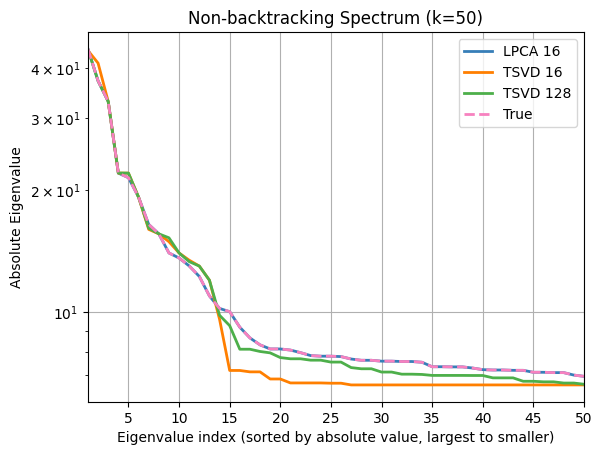

In [13]:
eig_true = eig_true_nb
spectra = spectra_nb

k = len(eig_true)
x = np.arange(1, k+1)

fig, ax = plt.subplots()

for label, eigs in spectra.items():
    kk = min(k, len(eigs))
    ax.semilogy(x[:kk], eigs[:kk], label=label, linewidth=2)
ax.semilogy(x, eig_true, label="True", linewidth=2, linestyle="--")

ax.set_xticks(np.arange(0, k+1, 5))
ax.set_xlim(1, k)

ax.set_xlabel("Eigenvalue index (sorted by absolute value, largest to smaller)")
ax.set_ylabel("Absolute Eigenvalue")
ax.set_title("Non-backtracking Spectrum (k={})".format(k))
ax.grid()
ax.legend()
plt.show()